# ADF test

This notebook illustrates the Augmented Dickey-Fuller (ADF) test with crypto data downloaded through `vectorbt`.

The main idea is simple:

- raw prices of major crypto assets often behave like non-stationary series;
- returns are usually much closer to stationary;
- a spread or detrended series is a more natural candidate for mean reversion.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

/opt/conda/lib/python3.11/site-packages/apscheduler/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
fixture_path = Path("../../../../../fixtures/crypto/crypto_daily_close.csv")

if not fixture_path.exists():
    raise FileNotFoundError(
        "Missing shared crypto fixture: fixtures/crypto/crypto_daily_close.csv. "
        "Run `python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive` "
        "from the repository root."
    )

close_matrix = pd.read_csv(fixture_path, parse_dates=["date"]).set_index("date").sort_index()
close_matrix = close_matrix.apply(pd.to_numeric, errors="coerce").dropna(how="all")

symbol = "BTCUSDT"
if symbol not in close_matrix:
    raise ValueError(f"Fixture is missing required symbol: {symbol}")

close = close_matrix[symbol].dropna()
close.name = "close"
close.tail()

0it [00:00, ?it/s]

Open time
2024-12-26 00:00:00+00:00   95,791.600000
2024-12-27 00:00:00+00:00   94,299.030000
2024-12-28 00:00:00+00:00   95,300.000000
2024-12-29 00:00:00+00:00   93,738.200000
2024-12-30 00:00:00+00:00   92,792.050000
Freq: D, Name: close, dtype: float64

In [3]:
log_price = np.log(close)
log_return = log_price.diff().dropna()

# A simple detrended series: distance from a 30-day rolling mean.
# This is not a tradable spread by itself, but it is useful to show how
# mean-reverting candidates differ from raw prices under the ADF test.
rolling_mean = log_price.rolling(30).mean()
demeaned_30d = (log_price - rolling_mean).dropna()

series_dict = {
    "BTC close": close,
    "BTC log price": log_price.dropna(),
    "BTC log return": log_return,
    "BTC log price minus 30d mean": demeaned_30d,
}

pd.DataFrame({name: s.tail(3) for name, s in series_dict.items()})

,BTC close,BTC log price,BTC log return,BTC log price minus 30d mean
Open time,,,,
2024-12-28 00:00:00+00:00,"95,300.000000",11.464785,0.010559,-0.034167
2024-12-29 00:00:00+00:00,"93,738.200000",11.448261,-0.016524,-0.049393
2024-12-30 00:00:00+00:00,"92,792.050000",11.438116,-0.010145,-0.058264


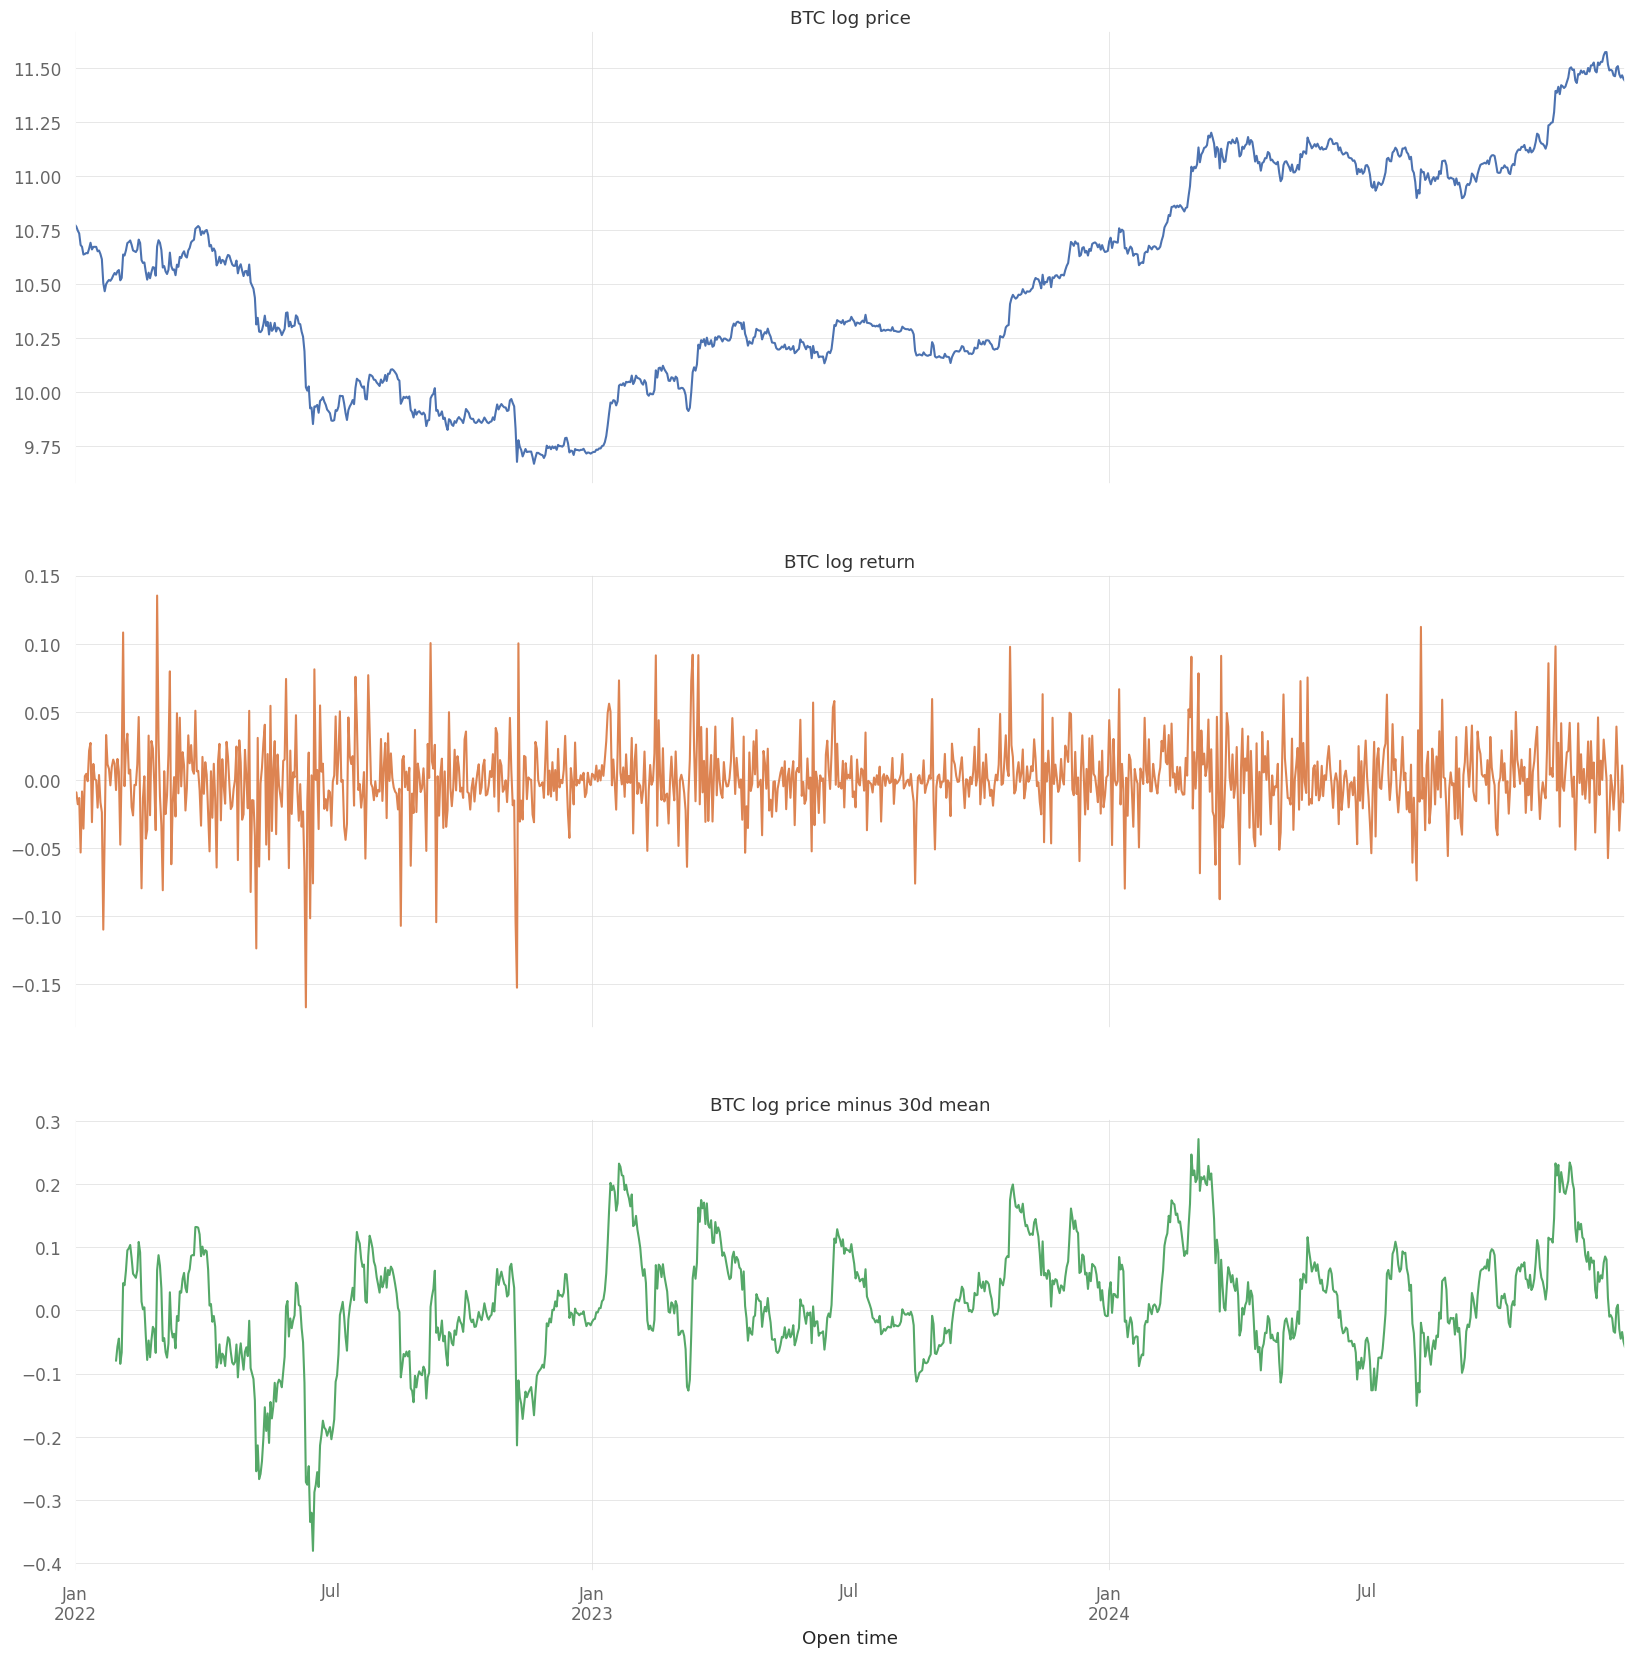

In [17]:
plot_df = pd.concat(
    {
        "log price": log_price,
        "log return": log_return,
        "log price - 30d mean": demeaned_30d,
    },
    axis=1,
)

plot_df.plot(
    subplots=True,
    figsize=(20, 20),
    title=["BTC log price", "BTC log return", "BTC log price minus 30d mean"],
    layout=(3, 1),
    legend=False,
);

In [5]:
def run_adf_test(series: pd.Series, name: str, regression: str = "c") -> pd.Series:
    """Run ADF on one series and return a compact summary."""
    cleaned = pd.Series(series).dropna()
    stat, pvalue, usedlag, nobs, critical_values, icbest = adfuller(
        cleaned,
        regression=regression,
        autolag="AIC",
    )
    return pd.Series(
        {
            "series": name,
            "adf_stat": stat,
            "p_value": pvalue,
            "used_lag": usedlag,
            "n_obs": nobs,
            "crit_1pct": critical_values["1%"],
            "crit_5pct": critical_values["5%"],
            "crit_10pct": critical_values["10%"],
            "reject_5pct": pvalue < 0.05,
        }
    )

In [6]:
results = pd.DataFrame(
    [run_adf_test(series, name) for name, series in series_dict.items()]
).set_index("series")

results

,adf_stat,p_value,used_lag,n_obs,crit_1pct,crit_5pct,crit_10pct,reject_5pct
series,,,,,,,,
BTC close,0.830471,0.992112,20,1074,-3.436453,-2.864235,-2.568205,False
BTC log price,-0.089989,0.950427,0,1094,-3.436342,-2.864186,-2.568179,False
BTC log return,-22.382005,0.000000,1,1092,-3.436353,-2.864190,-2.568181,True
BTC log price minus 30d mean,-5.304074,0.000005,2,1063,-3.436517,-2.864263,-2.568220,True


In [11]:
summary_df = results.copy()
summary_df["verdict_5pct"] = np.where(
    summary_df["reject_5pct"],
    "reject unit root",
    "fail to reject unit root",
)
summary_df[["adf_stat", "p_value", "used_lag", "n_obs", "verdict_5pct"]]

,adf_stat,p_value,used_lag,n_obs,verdict_5pct
series,,,,,
BTC close,0.830471,0.992112,20,1074,fail to reject unit root
BTC log price,-0.089989,0.950427,0,1094,fail to reject unit root
BTC log return,-22.382005,0.000000,1,1092,reject unit root
BTC log price minus 30d mean,-5.304074,0.000005,2,1063,reject unit root


## Interpretation

Typical outcomes are:

- `BTC close` and `BTC log price`: usually fail to reject the unit-root null, so they look non-stationary;
- `BTC log return`: often rejects the unit-root null, consistent with stationary fluctuations around zero;
- `BTC log price minus 30d mean`: often looks much more mean-reverting than the raw price.

For mean-reversion trading, the ADF test is usually more informative on a spread, residual, or detrended series than on the raw crypto price itself.